(0, 0, 7, 53)
(0, 0, 7, 8)
Time for game: 0.197666, Time for game2: 0.034800
(array([1626.893, 1667.093, 1681.508, 1686.449, 1667.591, 1664.864,
       1632.479, 1568.618, 1703.129, 1655.588, 1662.299, 1738.274,
       1702.859, 1659.308, 1645.409, 1640.978, 1650.683, 1663.67 ,
       1706.375, 1664.372, 1599.884, 1691.255, 1682.567, 1609.031,
       1682.519, 1584.599, 1681.448, 1625.462, 1716.014, 1706.372,
       1582.025, 1674.005, 1663.283, 1607.615, 1602.014, 1789.742,
       1644.125, 1592.216, 1588.298, 1622.762, 1619.357, 1634.681,
       1756.178, 1597.754, 1676.09 , 1718.39 , 1727.111, 1660.904,
       1642.538, 1603.007, 1587.428, 1710.104, 1748.786, 1682.654,
       1613.717, 1702.817, 1725.173, 1634.264, 1721.621, 1750.952,
       1750.43 , 1652.525, 1722.941, 1692.896, 1648.751, 1658.348,
       1701.938, 1687.442, 1709.669, 1693.619, 1617.761, 1628.339,
       1654.853, 1820.255, 1669.727, 1707.434, 1621.94 , 1639.325,
       1616.72 , 1597.748, 1639.187, 1648.862, 1625

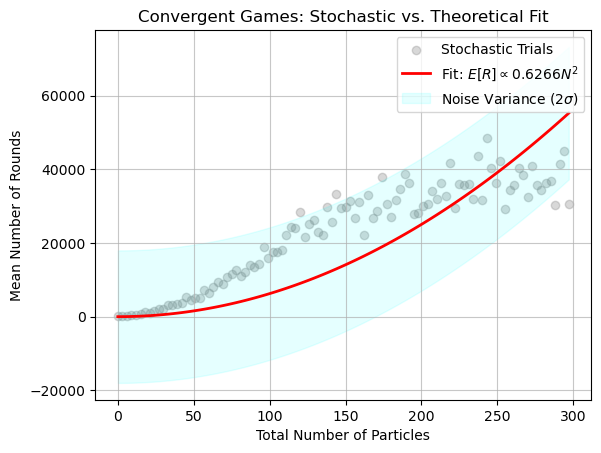

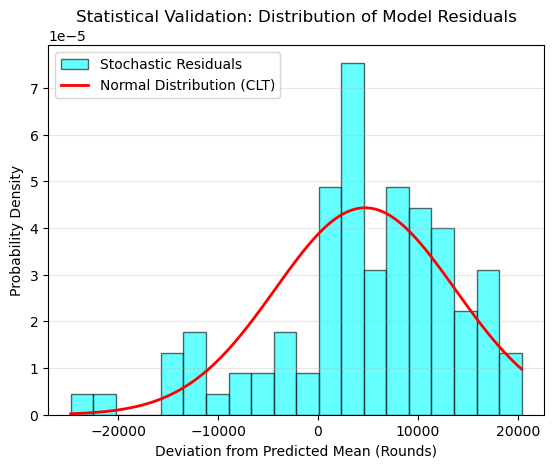

In [237]:
import numpy as np
import random as rd
import matplotlib.pyplot as plt
import time
from scipy.optimize import curve_fit

numA = 5
numB = 2
numC = 0
rounds = 90000

def checkA(numA):
    if numA == 0:
        return False
    else:
        return True
    
def checkB(numB):
    if numB == 0:
        return False
    else:
        return True
    
def checkC(numC):
    if numC == 0:
        return False
    else:
        return True
    
def check(numA, numB, numC):
    
    Aboo = True
    Bboo = True
    Cboo = True
    
    if numA == 0:
        Aboo = False
    elif numB == 0:
        Bboo = False
    elif numC == 0:
        Cboo = False
    
    return [Aboo, Bboo, Cboo]

def game(numA, numB, numC, rounds):
    
    AB = 0
    BC = 1
    AC = 2
    cols = [AB, BC, AC]
    probs = [1/3, 1/3, 1/3]
    count = 0
    
    for i in range(rounds):
        
        if (checkA(numA) == True) and (checkB(numB) == True) and (checkC(numC) == True):
            probs = [1/3, 1/3, 1/3]
        elif checkA(numA) == False:
            probs = [0, 1, 0]
        elif checkB(numB) == False:
            probs = [0, 0, 1]
        elif checkC(numC) == False:
            probs = [1, 0, 0]
            
        turn = np.random.choice(cols, p=probs, size=1)
        
        if turn[0] == AB:
            numA -= 1
            numB -= 1
            numC += 2
        elif turn[0] == BC:
            numB -= 1
            numC -= 1
            numA += 2
        else:
            numA -= 1
            numC -= 1
            numB += 2
            
        checks = [checkA(numA), checkB(numB), checkC(numC)]
        cond1 = [False, False, True]
        cond2 = [True, False, False]
        cond3 = [False, True, False]
        count += 1
        
        if (checks == cond1) or (checks == cond2) or (checks == cond3):
            break
            
    return numA, numB, numC, count
        
def game2(numA, numB, numC, rounds):
    
    a, b, c = int(numA), int(numB), int(numC)
    count = 0
    #print(f"start: {numA} A, {numB} B, {numC} C")
    for j in range(rounds):
            
        options = []
        if (a > 0) and (b > 0):
            options.append('AB')
        if (b > 0) and (c > 0):
            options.append('BC')
        if (a > 0) and (c > 0):
            options.append('AC')
            
        if not options:
            #print(f"ended at round {j}")
            break
            
        turn = rd.choice(options)    
            
        if turn == 'AB':
            a -= 1; b -= 1; c += 2
        elif turn == 'BC':
            a += 2; b -= 1; c -= 1
        elif turn == 'AC':
            a -= 1; b += 2; c -= 1
    
        count += 1
    
    return a, b, c, count

# game2 is a flop and not saving me that much time
# nevermind I managed to fix it and now the world is a better place :D
    
def multisamp(n):
    
    global numA, numB, numC, rounds
    gamesamps = []
    
    for i in range(n):
        newgami = game2(numA, numB, numC, rounds)
        roundval = newgami[3]
        gamesamps.append(roundval)
        
    return gamesamps

def multisampdiff(m, n):
    
    global numA, numB, numC, rounds
    gamesamps = []
    valCs = []
    
    for i in range(m):
        
        numCi = numC + 3*i
        valCs.append(numCi)
        gamesampsi = []
        
        for j in range(n):
            
            newgamj = game2(numA, numB, numCi, rounds)
            roundval = newgamj[3]
            gamesampsi.append(roundval)

        gamesampsiarr = np.array(gamesampsi)
        gamesampsimean = np.mean(gamesampsiarr)
        gamesamps.append(gamesampsimean)
        
    return np.array(valCs), np.array(gamesamps)
            
def meansamps(m, n):
    
    means = []
    
    for j in range(m):
        samp = multisamp(n)
        samparr = np.array(samp)
        sampmean = np.mean(samparr)
        means.append(sampmean)
    
    meansarr = np.array(means)
    meanOmeans = np.mean(meansarr)
    
    return meansarr, meanOmeans

def multisampany(n, a, b, c, turns):
    
    gamesamps = []
    
    for i in range(n):
        newgami = game2(a, b, c, turns)
        roundval = newgami[3]
        gamesamps.append(roundval)
        
    return gamesamps

def meansampsany(m, n, a, b, c, turns):
    
    means = []
    
    for j in range(m):
        samp = multisampany(n, a, b, c, turns)
        samparr = np.array(samp)
        sampmean = np.mean(samparr)
        means.append(sampmean)
    
    meansarr = np.array(means)
    meanOmeans = np.mean(meansarr)
    
    return meansarr, meanOmeans
    
def quadratic(N, a):
    return a * (N**2)
    
meansamp = meansampsany(100, 1000, 8, 10, 11, 90000)
startgame = time.perf_counter()
gameEG = game(numA, numB, numC, rounds)
endgame = time.perf_counter()
startgame2 = time.perf_counter()
game2EG = game2(numA, numB, numC, rounds)
endgame2 = time.perf_counter()

totgame = endgame - startgame
totgame2 = endgame2 - startgame2
durgame = (totgame / gameEG[3]) * 1000
durgame2 = (totgame2 / game2EG[3]) * 1000

x, y = multisampdiff(100, 100)
popt, pcov = curve_fit(quadratic, x, y)
aopt = popt[0]
predictions = quadratic(np.array(x), aopt)
residuals = np.array(y) - predictions
nsmooth = np.linspace(min(x), max(x), 100)
stderr = np.std(residuals)

print(gameEG)
print(game2EG)
print(f"Time for game: {durgame:.6f}, Time for game2: {durgame2:.6f}") 
print(meansamp)

plt.scatter(x, y, marker='o', alpha=0.3, label='Stochastic Trials', color='grey')
plt.plot(nsmooth, quadratic(nsmooth, aopt), color='red', linewidth=2, label=f'Fit: $E[R] \propto {aopt:.4f}N^2$')
plt.fill_between(nsmooth, quadratic(nsmooth, aopt) - 2*stderr, quadratic(nsmooth, aopt) + 2*stderr, color='cyan', alpha=0.1, label=f'Noise Variance ($2\sigma$)')
plt.grid(True, alpha=0.7)
plt.title("Convergent Games: Stochastic vs. Theoretical Fit")
plt.xlabel("Total Number of Particles")
plt.ylabel("Mean Number of Rounds")
plt.legend()
plt.show()

mu = np.mean(residuals)
sigma = np.std(residuals)
count, bins, ignored = plt.hist(residuals, bins=20, density=True, color='cyan', alpha=0.6, edgecolor='black', label='Stochastic Residuals')
x_bell = np.linspace(min(bins), max(bins), 100)
bell_curve = (1 / (sigma * np.sqrt(2 * np.pi))) * np.exp(-0.5 * ((x_bell - mu) / sigma)**2)

plt.plot(x_bell, bell_curve, color='red', linewidth=2, label='Normal Distribution (CLT)')
plt.title("Statistical Validation: Distribution of Model Residuals")
plt.xlabel("Deviation from Predicted Mean (Rounds)")
plt.ylabel("Probability Density")
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [236]:
import numpy as np
import sympy as sp

def game2(numA, numB, numC, rounds):
    
    a, b, c = int(numA), int(numB), int(numC)
    count = 0
    #print(f"start: {numA} A, {numB} B, {numC} C")
    for j in range(rounds):
            
        options = []
        if (a > 0) and (b > 0):
            options.append('AB')
        if (b > 0) and (c > 0):
            options.append('BC')
        if (a > 0) and (c > 0):
            options.append('AC')
            
        if not options:
            #print(f"ended at round {j}")
            break
            
        turn = rd.choice(options)    
            
        if turn == 'AB':
            a -= 1; b -= 1; c += 2
        elif turn == 'BC':
            a += 2; b -= 1; c -= 1
        elif turn == 'AC':
            a -= 1; b += 2; c -= 1
    
        count += 1
    
    return a, b, c, count

def numpos(N):
    
    count = 0
    
    for a in range(N + 1):
        for b in range(N + 1 - a):
            count += 1
            
    return count

def convtest(N):
    
    n = sp.Symbol('n')
    upper = 2*n**2 + 6*n
    lower = 3*n**2 + 9*n + 6
    expr = 1 - (upper / lower)
    res = expr.subs(n, N)
    
    return res

print(convtest(3))

for j in range(3,10):
    print(convtest(j))
    
fractions = []
for k in range(100):
    val = convtest(k+3)
    fractions.append(val)

print(fractions)
    
for i in range(1, 10):
    print(numpos(i))

2/5
2/5
17/45
23/63
5/14
19/54
47/135
19/55
[2/5, 17/45, 23/63, 5/14, 19/54, 47/135, 19/55, 34/99, 40/117, 31/91, 107/315, 61/180, 23/68, 155/459, 173/513, 32/95, 106/315, 233/693, 85/253, 139/414, 151/450, 109/325, 353/1053, 190/567, 68/203, 437/1305, 467/1395, 83/248, 265/792, 563/1683, 199/595, 316/945, 334/999, 235/703, 743/2223, 391/1170, 137/410, 863/2583, 905/2709, 158/473, 496/1485, 1037/3105, 361/1081, 565/1692, 589/1764, 409/1225, 1277/3825, 664/1989, 230/689, 1433/4293, 1487/4455, 257/770, 799/2394, 1655/4959, 571/1711, 886/2655, 916/2745, 631/1891, 1955/5859, 1009/3024, 347/1040, 2147/6435, 2213/6633, 380/1139, 1174/3519, 2417/7245, 829/2485, 1279/3834, 1315/3942, 901/2701, 2777/8325, 1426/4275, 488/1463, 3005/9009, 3083/9243, 527/1580, 1621/4860, 3323/9963, 1135/3403, 1744/5229, 1786/5355, 1219/3655, 3743/11223, 1915/5742, 653/1958, 4007/12015, 4097/12285, 698/2093, 2140/6417, 4373/13113, 1489/4465, 2281/6840, 2329/6984, 1585/4753, 4853/14553, 2476/7425, 842/2525, 5153/154